## 1. Reviewer Concern: Component Imbalance and Weight Selection

The reviewer noted that the composite structural manipulability score \(M(v)\) is empirically dominated by \(M_{\text{core}}\), while \(M_{\text{path}}\) contributes little node-level discrimination. To address this concern experimentally without reparsing Verilog, this notebook performs a fast GCN-based weight-sensitivity study using the already saved PyTorch-Geometric dataset (`gnn_structural_netlist_dataset.pt`). Since the saved dataset stores the final uniform score \(M(v)\) but not all four individual component arrays, we compute \(M_{\text{core}}\) and \(M_{\text{sym}}\) directly from the saved graph and recover the residual \(M_{\text{path}}+M_{\text{cent}}\) from the uniform target. We then compare uniform, core-light, and core-heavy weighting schemes. This experiment does not claim to find an optimal weighting because no external ground truth for ECO effort, edit cost, or attack feasibility is available. Instead, it shows whether reducing or increasing the core weight changes target composition and whether the resulting scores remain learnable by a representative GCN.

[INFO] Device: cpu
[INFO] Output directory: /data/desktop/rrk307/rupesh_projects/Mutability_analysis/reviewer_weight_sensitivity_outputs_fast
[INFO] Loaded dataset
  #graphs        : 30
  all_gate_types : ['and', 'nand', 'nor', 'not', 'or', 'xor']
  feat_dim (x)   : 10
  example circuits: ['c17.v', 'c432.v', 'c499.v', 'ctrl.v', 'c880.v']
[COMP] Computing fast components for 1/30: c17.v
[COMP] Computing fast components for 2/30: c432.v
[COMP] Computing fast components for 3/30: c499.v
[COMP] Computing fast components for 4/30: ctrl.v
[COMP] Computing fast components for 5/30: c880.v
[COMP] Computing fast components for 6/30: int2float.v
[COMP] Computing fast components for 7/30: router.v
[COMP] Computing fast components for 8/30: c1908.v
[COMP] Computing fast components for 9/30: c1355.v
[COMP] Computing fast components for 10/30: dec.v
[COMP] Computing fast components for 11/30: c2670.v
[COMP] Computing fast components for 12/30: c3540.v
[COMP] Computing fast components for 13/30: cavl

,scheme,weights,mse,mae,spearman,rho_core,rho_sym,rho_flow,target_std
0,uniform,"(0.25, 0.25, 0.25, 0.25)",0.000405 ± 0.000076,0.012738 ± 0.001813,0.6970 ± 0.0254,0.8405 ± 0.0317,0.5169 ± 0.1084,0.1700 ± 0.2228,0.0413 ± 0.0011
1,core_light,"(0.30, 0.10, 0.30, 0.30)",0.000094 ± 0.000014,0.007725 ± 0.000451,0.8139 ± 0.0050,0.8396 ± 0.0312,0.5178 ± 0.1082,0.1705 ± 0.2217,0.0180 ± 0.0002
2,core_heavy,"(0.20, 0.40, 0.20, 0.20)",0.000971 ± 0.000188,0.018450 ± 0.003245,0.6823 ± 0.0158,0.8405 ± 0.0317,0.5169 ± 0.1084,0.1699 ± 0.2228,0.0653 ± 0.0021


[SAVE] Summary: /data/desktop/rrk307/rupesh_projects/Mutability_analysis/reviewer_weight_sensitivity_outputs_fast/weight_sensitivity_fast_summary.csv

=== LaTeX table draft ===
\begin{tabular}{llllllll}
\toprule
Scheme & Weights & MSE & MAE & Spearman & $\rho(M_{\mathbf{w}},M_{\text{core}})$ & $\rho(M_{\mathbf{w}},M_{\text{sym}})$ & $\rho(M_{\mathbf{w}},M_{\text{path}}+M_{\text{cent}})$ \\
\midrule
uniform & (0.25, 0.25, 0.25, 0.25) & 0.000405 ± 0.000076 & 0.012738 ± 0.001813 & 0.6970 ± 0.0254 & 0.8405 ± 0.0317 & 0.5169 ± 0.1084 & 0.1700 ± 0.2228 \\
core_light & (0.30, 0.10, 0.30, 0.30) & 0.000094 ± 0.000014 & 0.007725 ± 0.000451 & 0.8139 ± 0.0050 & 0.8396 ± 0.0312 & 0.5178 ± 0.1082 & 0.1705 ± 0.2217 \\
core_heavy & (0.20, 0.40, 0.20, 0.20) & 0.000971 ± 0.000188 & 0.018450 ± 0.003245 & 0.6823 ± 0.0158 & 0.8405 ± 0.0317 & 0.5169 ± 0.1084 & 0.1699 ± 0.2228 \\
\bottomrule
\end{tabular}

[SAVE] LaTeX table: /data/desktop/rrk307/rupesh_projects/Mutability_analysis/reviewer_weight_sensitivit

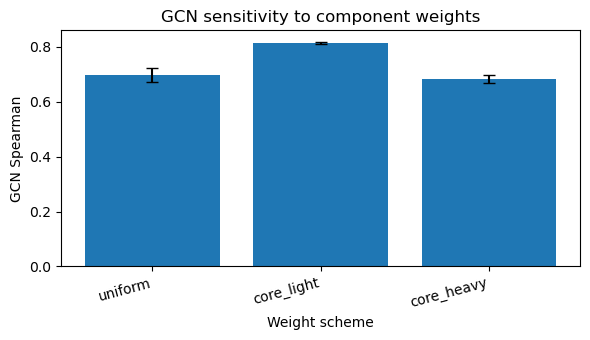

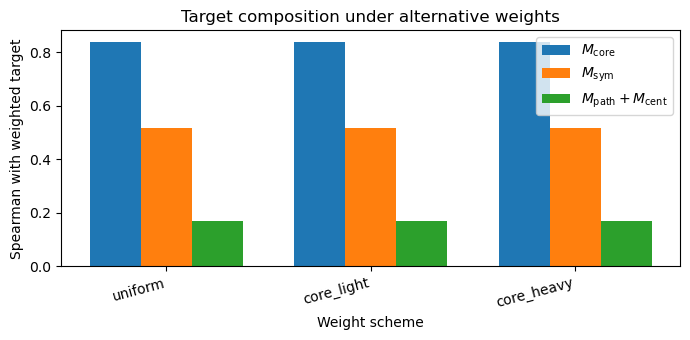

[SAVE] Spearman plot: /data/desktop/rrk307/rupesh_projects/Mutability_analysis/reviewer_weight_sensitivity_outputs_fast/weight_sensitivity_fast_spearman.pdf
[SAVE] Composition plot: /data/desktop/rrk307/rupesh_projects/Mutability_analysis/reviewer_weight_sensitivity_outputs_fast/weight_sensitivity_fast_composition.pdf

[DONE] Fast weight-sensitivity experiment completed.


In [3]:
# Fast reviewer-response experiment:
# GCN sensitivity to component weights using the saved PyG dataset.
#
# This avoids Verilog parsing. It loads:
#   gnn_structural_netlist_dataset.pt
#
# Important:
# The saved dataset contains the final uniform target y, not the four
# individual component arrays. Therefore, this experiment reconstructs:
#   M_core       from k-core decomposition on the saved graph,
#   M_sym        from a fast WL-style structural grouping,
#   M_flow_sum   = M_path + M_cent = 4*M_uniform - M_core - M_sym.
#
# Weight schemes are restricted to w_path = w_cent so that:
#   M_w = w_core*M_core + w_sym*M_sym + w_path*(M_path + M_cent)
#
# This is sufficient to test core-dominance sensitivity efficiently.

import os
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
from torch import nn
import networkx as nx
import matplotlib.pyplot as plt

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv


# ============================================================
# 0. Configuration
# ============================================================

LOAD_PATH = "gnn_structural_netlist_dataset.pt"
OUTPUT_DIR = Path("reviewer_weight_sensitivity_outputs_fast")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEEDS = [0, 1]          # use [0,1,2,3,4] if you want a stronger table
NUM_EPOCHS = 10         # increase to 30 if runtime is acceptable
TRAIN_RATIO = 0.8
BATCH_SIZE = 4
HIDDEN_DIM = 64
NUM_LAYERS = 3
LR = 1e-3

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Weight order:
#   (M_path, M_core, M_sym, M_cent)
# In this fast residual mode, M_path and M_cent must have equal weights.
WEIGHT_SCHEMES = {
    "uniform":    np.array([0.25, 0.25, 0.25, 0.25], dtype=np.float32),
    "core_light": np.array([0.30, 0.10, 0.30, 0.30], dtype=np.float32),
    "core_heavy": np.array([0.20, 0.40, 0.20, 0.20], dtype=np.float32),
}

CACHE_PATH = OUTPUT_DIR / "core_sym_flow_cache.pt"

print("[INFO] Device:", DEVICE)
print("[INFO] Output directory:", OUTPUT_DIR.resolve())


# ============================================================
# 1. Load saved dataset
# ============================================================

def safe_torch_load(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")

obj = safe_torch_load(LOAD_PATH)

data_list = obj["data_list"]
all_gate_types = obj["all_gate_types"]
gate_type_to_idx = obj["gate_type_to_idx"]

num_gate_types = len(all_gate_types)

print("[INFO] Loaded dataset")
print("  #graphs        :", len(data_list))
print("  all_gate_types :", all_gate_types)
print("  feat_dim (x)   :", data_list[0].x.size(-1))
print("  example circuits:", [d.circuit_name for d in data_list[:5]])

if len(data_list) == 0:
    raise RuntimeError("data_list is empty.")


# ============================================================
# 2. Utility: Spearman correlation
# ============================================================

def spearmanr_np(y_true, y_pred):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    if y_true.size < 2:
        return np.nan

    r1 = pd.Series(y_true).rank(method="average").to_numpy()
    r2 = pd.Series(y_pred).rank(method="average").to_numpy()

    r1_mean = r1.mean()
    r2_mean = r2.mean()

    num = np.sum((r1 - r1_mean) * (r2 - r2_mean))
    den = np.sqrt(np.sum((r1 - r1_mean) ** 2) * np.sum((r2 - r2_mean) ** 2))

    if den == 0:
        return np.nan
    return float(num / den)


def mean_std_str(values, precision=4):
    values = pd.Series(values).dropna().astype(float)
    if len(values) == 0:
        return "nan"
    if len(values) == 1:
        return f"{values.iloc[0]:.{precision}f}"
    return f"{values.mean():.{precision}f} ± {values.std(ddof=1):.{precision}f}"


# ============================================================
# 3. Fast reconstruction of M_core, M_sym, and residual flow
# ============================================================

def build_nx_graph_from_pyg(d):
    num_nodes = d.num_nodes
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))

    edge_index = d.edge_index.cpu().numpy()
    for u, v in edge_index.T:
        u = int(u)
        v = int(v)
        if u != v:
            G.add_edge(u, v)

    return G


def infer_initial_colors(d):
    """
    Uses saved feature layout from your preprocessing:
      [gate-type one hot, is_input, is_output, fan_in, fan_out]
    """
    x = d.x.cpu()
    gate_mask = d.gate_mask.cpu().bool()

    is_input_col = num_gate_types + 0
    is_output_col = num_gate_types + 1

    colors = []
    for i in range(d.num_nodes):
        if x[i, is_input_col].item() > 0.5:
            colors.append("input")
        elif x[i, is_output_col].item() > 0.5:
            colors.append("output")
        elif gate_mask[i].item():
            one_hot = x[i, :num_gate_types]
            if one_hot.numel() > 0 and float(one_hot.max()) > 0:
                gate_idx = int(torch.argmax(one_hot).item())
                colors.append(f"gate:{all_gate_types[gate_idx]}")
            else:
                colors.append("gate:unknown")
        else:
            colors.append("unknown")

    return colors


def wl_symmetry_score(G, init_colors, num_iter=2):
    """
    Fast WL-style structural class score:
      M_sym(v) = |class(v)| / |V|
    """
    n = len(init_colors)
    colors = {i: init_colors[i] for i in range(n)}

    for _ in range(num_iter):
        new_colors = {}
        for v in range(n):
            neigh_colors = sorted(colors[u] for u in G.neighbors(v))
            new_colors[v] = str((colors[v], tuple(neigh_colors)))
        colors = new_colors

    class_count = defaultdict(int)
    for c in colors.values():
        class_count[c] += 1

    sym = np.zeros(n, dtype=np.float32)
    for v in range(n):
        sym[v] = class_count[colors[v]] / float(max(1, n))

    return sym


def core_score(G):
    n = G.number_of_nodes()

    if n == 0:
        return np.zeros(0, dtype=np.float32)

    try:
        if G.number_of_edges() > 0:
            core_num = nx.core_number(G)
        else:
            core_num = {v: 0 for v in G.nodes()}
    except Exception:
        core_num = {v: 0 for v in G.nodes()}

    max_core = max(core_num.values()) if len(core_num) > 0 else 1
    if max_core == 0:
        max_core = 1

    core = np.zeros(n, dtype=np.float32)
    for v in range(n):
        core[v] = float(core_num.get(v, 0)) / float(max_core)

    return core


def compute_fast_components(data_list):
    """
    Computes and attaches:
      d.M_core_fast
      d.M_sym_fast
      d.M_flow_fast = M_path + M_cent
    """
    cache = {}

    if CACHE_PATH.exists():
        print("[INFO] Loading cached fast components:", CACHE_PATH)
        cache = safe_torch_load(CACHE_PATH)

    updated_cache = dict(cache)

    for idx, d in enumerate(data_list):
        cname = str(d.circuit_name)

        if cname in cache:
            entry = cache[cname]
            if int(entry["num_nodes"]) == int(d.num_nodes):
                d.M_core_fast = entry["M_core"].clone()
                d.M_sym_fast = entry["M_sym"].clone()
                d.M_flow_fast = entry["M_flow"].clone()
                continue

        print(f"[COMP] Computing fast components for {idx+1}/{len(data_list)}: {cname}")

        G = build_nx_graph_from_pyg(d)

        M_core = core_score(G)
        init_colors = infer_initial_colors(d)
        M_sym = wl_symmetry_score(G, init_colors, num_iter=2)

        # Saved y is the uniform target:
        # y = 0.25*(M_path + M_core + M_sym + M_cent)
        # therefore:
        # M_path + M_cent = 4*y - M_core - M_sym
        y_uniform = d.y.cpu().numpy().reshape(-1).astype(np.float32)
        M_flow = 4.0 * y_uniform - M_core - M_sym

        # Small numerical or preprocessing mismatch can cause tiny violations.
        # The valid range for M_path + M_cent is [0,2].
        min_flow = float(M_flow.min())
        max_flow = float(M_flow.max())
        if min_flow < -1e-3 or max_flow > 2.0 + 1e-3:
            print(
                f"  [WARN] residual flow outside [0,2] before clipping: "
                f"min={min_flow:.4f}, max={max_flow:.4f}"
            )

        M_flow = np.clip(M_flow, 0.0, 2.0).astype(np.float32)

        d.M_core_fast = torch.from_numpy(M_core).view(-1, 1)
        d.M_sym_fast = torch.from_numpy(M_sym).view(-1, 1)
        d.M_flow_fast = torch.from_numpy(M_flow).view(-1, 1)

        updated_cache[cname] = {
            "num_nodes": int(d.num_nodes),
            "M_core": d.M_core_fast.clone(),
            "M_sym": d.M_sym_fast.clone(),
            "M_flow": d.M_flow_fast.clone(),
        }

    torch.save(updated_cache, CACHE_PATH)
    print("[INFO] Saved fast component cache:", CACHE_PATH.resolve())

compute_fast_components(data_list)


# Quick sanity check: uniform reconstruction should match saved y closely.
all_y = []
all_y_recon = []
for d in data_list:
    y_recon = (
        0.25 * d.M_flow_fast +
        0.25 * d.M_core_fast +
        0.25 * d.M_sym_fast
    )
    all_y.append(d.y.view(-1, 1))
    all_y_recon.append(y_recon)

all_y = torch.cat(all_y, dim=0).numpy().flatten()
all_y_recon = torch.cat(all_y_recon, dim=0).numpy().flatten()

print("[SANITY] Uniform target reconstruction")
print("  MSE:", np.mean((all_y - all_y_recon) ** 2))
print("  MAE:", np.mean(np.abs(all_y - all_y_recon)))
print("  Spearman:", spearmanr_np(all_y, all_y_recon))


# ============================================================
# 4. Weighted target construction
# ============================================================

def clone_with_weighted_target(dataset, weights):
    """
    weights are ordered as:
      (M_path, M_core, M_sym, M_cent)

    Fast residual mode requires:
      w_path == w_cent

    Target:
      M_w = w_core*M_core + w_sym*M_sym + w_path*(M_path + M_cent)
    """
    w_path, w_core, w_sym, w_cent = [float(x) for x in weights]

    if abs(w_path - w_cent) > 1e-8:
        raise ValueError(
            "Fast residual mode requires w_path == w_cent because "
            "the saved dataset does not store M_path and M_cent separately."
        )

    new_dataset = []

    for d in dataset:
        target = (
            w_path * d.M_flow_fast +
            w_core * d.M_core_fast +
            w_sym  * d.M_sym_fast
        ).float()

        nd = Data(
            x=d.x.clone(),
            edge_index=d.edge_index.clone(),
            y=target.clone(),
        )

        nd.gate_mask = d.gate_mask.clone()
        nd.circuit_name = d.circuit_name

        nd.M_core_fast = d.M_core_fast.clone()
        nd.M_sym_fast = d.M_sym_fast.clone()
        nd.M_flow_fast = d.M_flow_fast.clone()

        gate_mask = nd.gate_mask
        y_gate = nd.y[gate_mask]

        if y_gate.numel() == 0:
            mean = 0.0
            std = 1.0
        else:
            mean = y_gate.mean().item()
            std = y_gate.std().item()
            if std < 1e-6:
                std = 1.0

        nd.y_mean = torch.full_like(nd.y, mean)
        nd.y_std = torch.full_like(nd.y, std)
        nd.y_norm = (nd.y - nd.y_mean) / nd.y_std

        new_dataset.append(nd)

    return new_dataset


# ============================================================
# 5. GCN model and training
# ============================================================

class GCNRegressor(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_layers=3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_dim, hidden_dim))

        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))

        self.convs.append(GCNConv(hidden_dim, hidden_dim))
        self.act = nn.ReLU()
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index):
        h = x
        for conv in self.convs:
            h = conv(h, edge_index)
            h = self.act(h)
        return self.out(h)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_and_evaluate_gcn(train_dataset, test_dataset, seed):
    set_seed(seed)

    in_dim = train_dataset[0].x.size(-1)

    model = GCNRegressor(
        in_dim=in_dim,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    model.train()

    for epoch in range(1, NUM_EPOCHS + 1):
        total_loss = 0.0
        total_gates = 0

        for batch in train_loader:
            batch = batch.to(DEVICE)

            pred_norm = model(batch.x, batch.edge_index)
            gate_mask = batch.gate_mask

            pred_gate_norm = pred_norm[gate_mask]
            y_gate_norm = batch.y_norm[gate_mask]

            if pred_gate_norm.numel() == 0:
                continue

            loss = loss_fn(pred_gate_norm, y_gate_norm)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            num_gates = int(gate_mask.sum().item())
            total_loss += loss.item() * num_gates
            total_gates += num_gates

        avg_loss = total_loss / max(1, total_gates)

    # Evaluation.
    model.eval()

    all_true = []
    all_pred = []
    all_core = []
    all_sym = []
    all_flow = []
    per_circuit = []

    with torch.no_grad():
        for data in test_dataset:
            d = data.to(DEVICE)

            pred_norm = model(d.x, d.edge_index)
            pred = (pred_norm * d.y_std + d.y_mean).cpu().numpy().flatten()

            y_true = d.y.cpu().numpy().flatten()
            gate_mask = d.gate_mask.cpu().numpy().astype(bool)

            y_gate = y_true[gate_mask]
            pred_gate = pred[gate_mask]

            if y_gate.size == 0:
                continue

            core_gate = data.M_core_fast.cpu().numpy().flatten()[gate_mask]
            sym_gate = data.M_sym_fast.cpu().numpy().flatten()[gate_mask]
            flow_gate = data.M_flow_fast.cpu().numpy().flatten()[gate_mask]

            all_true.append(y_gate)
            all_pred.append(pred_gate)
            all_core.append(core_gate)
            all_sym.append(sym_gate)
            all_flow.append(flow_gate)

            per_circuit.append({
                "seed": seed,
                "circuit": data.circuit_name,
                "num_gate_nodes": int(gate_mask.sum()),
                "mse": float(np.mean((y_gate - pred_gate) ** 2)),
                "mae": float(np.mean(np.abs(y_gate - pred_gate))),
                "spearman": spearmanr_np(y_gate, pred_gate),
            })

    all_true = np.concatenate(all_true, axis=0)
    all_pred = np.concatenate(all_pred, axis=0)
    all_core = np.concatenate(all_core, axis=0)
    all_sym = np.concatenate(all_sym, axis=0)
    all_flow = np.concatenate(all_flow, axis=0)

    result = {
        "mse": float(np.mean((all_true - all_pred) ** 2)),
        "mae": float(np.mean(np.abs(all_true - all_pred))),
        "spearman": spearmanr_np(all_true, all_pred),
        "target_std": float(np.std(all_true)),
        "rho_target_core": spearmanr_np(all_true, all_core),
        "rho_target_sym": spearmanr_np(all_true, all_sym),
        "rho_target_flow": spearmanr_np(all_true, all_flow),
    }

    return result, per_circuit


# ============================================================
# 6. Main experiment
# ============================================================

raw_rows = []
per_circuit_rows = []

for seed in SEEDS:
    print("\n" + "=" * 70)
    print(f"[SEED {seed}]")

    indices = list(range(len(data_list)))
    rnd = random.Random(seed)
    rnd.shuffle(indices)

    split = int(TRAIN_RATIO * len(indices))
    train_indices = indices[:split]
    test_indices = indices[split:]

    train_base = [data_list[i] for i in train_indices]
    test_base = [data_list[i] for i in test_indices]

    print("[SPLIT] Train:", [d.circuit_name for d in train_base])
    print("[SPLIT] Test :", [d.circuit_name for d in test_base])

    for scheme_name, weights in WEIGHT_SCHEMES.items():
        print(f"\n[RUN] {scheme_name}: weights={weights.tolist()}")

        train_dataset = clone_with_weighted_target(train_base, weights)
        test_dataset = clone_with_weighted_target(test_base, weights)

        result, pc = train_and_evaluate_gcn(
            train_dataset=train_dataset,
            test_dataset=test_dataset,
            seed=seed,
        )

        row = {
            "seed": seed,
            "scheme": scheme_name,
            "w_path": float(weights[0]),
            "w_core": float(weights[1]),
            "w_sym": float(weights[2]),
            "w_cent": float(weights[3]),
        }
        row.update(result)
        raw_rows.append(row)

        for p in pc:
            p.update({
                "scheme": scheme_name,
                "w_path": float(weights[0]),
                "w_core": float(weights[1]),
                "w_sym": float(weights[2]),
                "w_cent": float(weights[3]),
            })
            per_circuit_rows.append(p)

        print(
            f"[RESULT] MSE={result['mse']:.6f}, "
            f"MAE={result['mae']:.6f}, "
            f"Spearman={result['spearman']:.4f}, "
            f"rho_core={result['rho_target_core']:.4f}, "
            f"rho_flow={result['rho_target_flow']:.4f}"
        )


# ============================================================
# 7. Save and summarize
# ============================================================

results_df = pd.DataFrame(raw_rows)
per_circuit_df = pd.DataFrame(per_circuit_rows)

raw_csv = OUTPUT_DIR / "weight_sensitivity_fast_raw.csv"
pc_csv = OUTPUT_DIR / "weight_sensitivity_fast_per_circuit.csv"

results_df.to_csv(raw_csv, index=False)
per_circuit_df.to_csv(pc_csv, index=False)

print("\n[SAVE] Raw results:", raw_csv.resolve())
print("[SAVE] Per-circuit results:", pc_csv.resolve())

summary_rows = []

scheme_order = ["uniform", "core_light", "core_heavy"]

for scheme in scheme_order:
    group = results_df[results_df["scheme"] == scheme]
    if len(group) == 0:
        continue

    summary_rows.append({
        "scheme": scheme,
        "weights": "(" + ", ".join([
            f"{group['w_path'].mean():.2f}",
            f"{group['w_core'].mean():.2f}",
            f"{group['w_sym'].mean():.2f}",
            f"{group['w_cent'].mean():.2f}",
        ]) + ")",
        "mse": mean_std_str(group["mse"], precision=6),
        "mae": mean_std_str(group["mae"], precision=6),
        "spearman": mean_std_str(group["spearman"], precision=4),
        "rho_core": mean_std_str(group["rho_target_core"], precision=4),
        "rho_sym": mean_std_str(group["rho_target_sym"], precision=4),
        "rho_flow": mean_std_str(group["rho_target_flow"], precision=4),
        "target_std": mean_std_str(group["target_std"], precision=4),
    })

summary_df = pd.DataFrame(summary_rows)

summary_csv = OUTPUT_DIR / "weight_sensitivity_fast_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print("\n=== Weight sensitivity summary ===")
try:
    display(summary_df)
except NameError:
    print(summary_df.to_string(index=False))

print("[SAVE] Summary:", summary_csv.resolve())


# ============================================================
# 8. LaTeX table draft
# ============================================================

latex_df = summary_df[[
    "scheme", "weights", "mse", "mae", "spearman",
    "rho_core", "rho_sym", "rho_flow"
]].copy()

latex_df.columns = [
    "Scheme",
    "Weights",
    "MSE",
    "MAE",
    "Spearman",
    r"$\rho(M_{\mathbf{w}},M_{\text{core}})$",
    r"$\rho(M_{\mathbf{w}},M_{\text{sym}})$",
    r"$\rho(M_{\mathbf{w}},M_{\text{path}}+M_{\text{cent}})$",
]

latex_text = latex_df.to_latex(index=False, escape=False)
latex_path = OUTPUT_DIR / "weight_sensitivity_fast_table.tex"
latex_path.write_text(latex_text)

print("\n=== LaTeX table draft ===")
print(latex_text)
print("[SAVE] LaTeX table:", latex_path.resolve())


# ============================================================
# 9. Small plots
# ============================================================

plot_df = results_df.copy()

plt.figure(figsize=(6, 3.5))
means = plot_df.groupby("scheme")["spearman"].mean().reindex(scheme_order)
stds = plot_df.groupby("scheme")["spearman"].std().reindex(scheme_order).fillna(0.0)
x = np.arange(len(scheme_order))
plt.bar(x, means.values, yerr=stds.values, capsize=4)
plt.xticks(x, scheme_order, rotation=15, ha="right")
plt.ylabel("GCN Spearman")
plt.xlabel("Weight scheme")
plt.title("GCN sensitivity to component weights")
plt.tight_layout()
spearman_plot = OUTPUT_DIR / "weight_sensitivity_fast_spearman.pdf"
plt.savefig(spearman_plot)
plt.show()

plt.figure(figsize=(7, 3.5))
corr_cols = ["rho_target_core", "rho_target_sym", "rho_target_flow"]
corr_labels = [r"$M_{\mathrm{core}}$", r"$M_{\mathrm{sym}}$", r"$M_{\mathrm{path}}+M_{\mathrm{cent}}$"]
corr_means = plot_df.groupby("scheme")[corr_cols].mean().reindex(scheme_order)

x = np.arange(len(scheme_order))
width = 0.25

for i, col in enumerate(corr_cols):
    plt.bar(
        x + (i - 1) * width,
        corr_means[col].values,
        width=width,
        label=corr_labels[i],
    )

plt.xticks(x, scheme_order, rotation=15, ha="right")
plt.ylabel("Spearman with weighted target")
plt.xlabel("Weight scheme")
plt.title("Target composition under alternative weights")
plt.legend()
plt.tight_layout()
corr_plot = OUTPUT_DIR / "weight_sensitivity_fast_composition.pdf"
plt.savefig(corr_plot)
plt.show()

print("[SAVE] Spearman plot:", spearman_plot.resolve())
print("[SAVE] Composition plot:", corr_plot.resolve())

print("\n[DONE] Fast weight-sensitivity experiment completed.")

#### Cell 2: Weight-Sensitivity Study Across the Remaining GNN Architectures

This cell extends the GCN-based weight-sensitivity experiment from Cell 1 to the remaining nine GNN architectures used in the paper: GIN, GSAGE, GAT, MPNN, APPNP, G-U-Net, HetGNN, SGNN, and GTN. All models are trained using the same circuit-level splits, normalized gate-node targets, weight schemes, optimizer, hidden dimension, and number of message-passing layers wherever applicable. This keeps the comparison as fair as possible while evaluating whether alternative component weightings remain learnable beyond a single GCN model. The goal is not to identify an optimal architecture or optimal weights, but to test whether the reviewer-observed component imbalance is specific to one model or persists across different GNN inductive biases.

[INFO] Cell 2 device: cpu
[INFO] Models: ['GIN', 'GSAGE', 'GAT', 'MPNN', 'APPNP', 'G-U-Net', 'HetGNN', 'SGNN', 'GTN']
[INFO] Seeds: [0, 1]
[INFO] Epochs: 10
[INFO] Output directory: /data/desktop/rrk307/rupesh_projects/Mutability_analysis/reviewer_weight_sensitivity_outputs_all_gnns
[INFO] Input feature dimension: 10
[INFO] Inferred #gate types: 6
[INFO] Preparing negative edges for SGNN-like model...
[INFO] Negative edges prepared.

[SEED 0]
[SPLIT] Train: ['ctrl.v', 'c2670.v', 'c7552.v', 'c6288.v', 'int2float.v', 'c17.v', 'c1908.v', 'multiplier.v', 'div.v', 'c5315.v', 'max.v', 'sqrt.v', 'sin.v', 'c499.v', 'bar.v', 'c880.v', 'voter.v', 'router.v', 'c3540.v', 'arbiter.v', 'dec.v', 'memctrl.v', 'i2c.v', 'adder.v']
[SPLIT] Test : ['c1355.v', 'c432.v', 'Priority.v', 'square.v', 'cavlc.v', 'log2.v']

------------------------------------------------------------------------------------------
[SCHEME] uniform: weights=[0.25, 0.25, 0.25, 0.25]
[RUN] seed=0, scheme=uniform, model=GIN
      MSE=

,model,scheme,weights,mse,mae,spearman,rho_core,rho_sym,rho_flow,target_std
0,GIN,uniform,"(0.25, 0.25, 0.25, 0.25)",0.001222 ± 0.001153,0.016900 ± 0.007062,0.7784 ± 0.0183,0.8405 ± 0.0317,0.5169 ± 0.1084,0.1700 ± 0.2228,0.0413 ± 0.0011
1,GIN,core_light,"(0.30, 0.10, 0.30, 0.30)",0.000120 ± 0.000045,0.008011 ± 0.000789,0.7703 ± 0.0225,0.8396 ± 0.0312,0.5178 ± 0.1082,0.1705 ± 0.2217,0.0180 ± 0.0002
2,GIN,core_heavy,"(0.20, 0.40, 0.20, 0.20)",0.010760 ± 0.013739,0.036403 ± 0.025431,0.5614 ± 0.1649,0.8405 ± 0.0317,0.5169 ± 0.1084,0.1699 ± 0.2228,0.0653 ± 0.0021
3,GSAGE,uniform,"(0.25, 0.25, 0.25, 0.25)",0.000422 ± 0.000083,0.013435 ± 0.001949,0.7622 ± 0.0292,0.8405 ± 0.0317,0.5169 ± 0.1084,0.1700 ± 0.2228,0.0413 ± 0.0011
4,GSAGE,core_light,"(0.30, 0.10, 0.30, 0.30)",0.000092 ± 0.000016,0.007765 ± 0.000635,0.7810 ± 0.0438,0.8396 ± 0.0312,0.5178 ± 0.1082,0.1705 ± 0.2217,0.0180 ± 0.0002
5,GSAGE,core_heavy,"(0.20, 0.40, 0.20, 0.20)",0.001060 ± 0.000229,0.019744 ± 0.003278,0.7538 ± 0.0115,0.8405 ± 0.0317,0.5169 ± 0.1084,0.1699 ± 0.2228,0.0653 ± 0.0021
6,GAT,uniform,"(0.25, 0.25, 0.25, 0.25)",0.000414 ± 0.000184,0.012791 ± 0.002909,0.6927 ± 0.0259,0.8405 ± 0.0317,0.5169 ± 0.1084,0.1700 ± 0.2228,0.0413 ± 0.0011
7,GAT,core_light,"(0.30, 0.10, 0.30, 0.30)",0.000092 ± 0.000029,0.007633 ± 0.000880,0.7394 ± 0.0242,0.8396 ± 0.0312,0.5178 ± 0.1082,0.1705 ± 0.2217,0.0180 ± 0.0002
8,GAT,core_heavy,"(0.20, 0.40, 0.20, 0.20)",0.000998 ± 0.000501,0.018119 ± 0.005557,0.6861 ± 0.0330,0.8405 ± 0.0317,0.5169 ± 0.1084,0.1699 ± 0.2228,0.0653 ± 0.0021
9,MPNN,uniform,"(0.25, 0.25, 0.25, 0.25)",0.000449 ± 0.000110,0.013835 ± 0.001945,0.7495 ± 0.0258,0.8405 ± 0.0317,0.5169 ± 0.1084,0.1700 ± 0.2228,0.0413 ± 0.0011



=== Summary: All Models Including GCN if Available ===


,model,scheme,weights,mse,mae,spearman,rho_core,rho_sym,rho_flow,target_std
0,GCN,uniform,"(0.25, 0.25, 0.25, 0.25)",0.000405 ± 0.000076,0.012738 ± 0.001813,0.6970 ± 0.0254,0.8405 ± 0.0317,0.5169 ± 0.1084,0.1700 ± 0.2228,0.0413 ± 0.0011
1,GCN,core_light,"(0.30, 0.10, 0.30, 0.30)",0.000094 ± 0.000014,0.007725 ± 0.000451,0.8139 ± 0.0050,0.8396 ± 0.0312,0.5178 ± 0.1082,0.1705 ± 0.2217,0.0180 ± 0.0002
2,GCN,core_heavy,"(0.20, 0.40, 0.20, 0.20)",0.000971 ± 0.000188,0.018450 ± 0.003245,0.6823 ± 0.0158,0.8405 ± 0.0317,0.5169 ± 0.1084,0.1699 ± 0.2228,0.0653 ± 0.0021
3,GIN,uniform,"(0.25, 0.25, 0.25, 0.25)",0.001222 ± 0.001153,0.016900 ± 0.007062,0.7784 ± 0.0183,0.8405 ± 0.0317,0.5169 ± 0.1084,0.1700 ± 0.2228,0.0413 ± 0.0011
4,GIN,core_light,"(0.30, 0.10, 0.30, 0.30)",0.000120 ± 0.000045,0.008011 ± 0.000789,0.7703 ± 0.0225,0.8396 ± 0.0312,0.5178 ± 0.1082,0.1705 ± 0.2217,0.0180 ± 0.0002
5,GIN,core_heavy,"(0.20, 0.40, 0.20, 0.20)",0.010760 ± 0.013739,0.036403 ± 0.025431,0.5614 ± 0.1649,0.8405 ± 0.0317,0.5169 ± 0.1084,0.1699 ± 0.2228,0.0653 ± 0.0021
6,GSAGE,uniform,"(0.25, 0.25, 0.25, 0.25)",0.000422 ± 0.000083,0.013435 ± 0.001949,0.7622 ± 0.0292,0.8405 ± 0.0317,0.5169 ± 0.1084,0.1700 ± 0.2228,0.0413 ± 0.0011
7,GSAGE,core_light,"(0.30, 0.10, 0.30, 0.30)",0.000092 ± 0.000016,0.007765 ± 0.000635,0.7810 ± 0.0438,0.8396 ± 0.0312,0.5178 ± 0.1082,0.1705 ± 0.2217,0.0180 ± 0.0002
8,GSAGE,core_heavy,"(0.20, 0.40, 0.20, 0.20)",0.001060 ± 0.000229,0.019744 ± 0.003278,0.7538 ± 0.0115,0.8405 ± 0.0317,0.5169 ± 0.1084,0.1699 ± 0.2228,0.0653 ± 0.0021
9,GAT,uniform,"(0.25, 0.25, 0.25, 0.25)",0.000414 ± 0.000184,0.012791 ± 0.002909,0.6927 ± 0.0259,0.8405 ± 0.0317,0.5169 ± 0.1084,0.1700 ± 0.2228,0.0413 ± 0.0011


[SAVE] 9-GNN summary: /data/desktop/rrk307/rupesh_projects/Mutability_analysis/reviewer_weight_sensitivity_outputs_all_gnns/weight_sensitivity_remaining_9gnns_summary.csv
[SAVE] Combined summary: /data/desktop/rrk307/rupesh_projects/Mutability_analysis/reviewer_weight_sensitivity_outputs_all_gnns/weight_sensitivity_all_models_summary.csv

=== Mean Spearman Pivot ===


scheme,core_heavy,core_light,uniform
model,,,
APPNP,0.714775,0.794460,0.726578
G-U-Net,0.705639,0.761717,0.732720
GAT,0.686108,0.739357,0.692744
GCN,0.682273,0.813931,0.696960
GIN,0.561398,0.770290,0.778431
GSAGE,0.753826,0.780991,0.762186
GTN,0.759921,0.756681,0.743269
HetGNN,0.791513,0.801389,0.803574
MPNN,0.724697,0.742980,0.749469



=== Mean MSE Pivot ===


scheme,core_heavy,core_light,uniform
model,,,
APPNP,0.001001,0.000094,0.000413
G-U-Net,0.000958,0.000094,0.000404
GAT,0.000998,0.000092,0.000414
GCN,0.000971,0.000094,0.000405
GIN,0.010760,0.000120,0.001222
GSAGE,0.001060,0.000092,0.000422
GTN,0.001068,0.000098,0.000457
HetGNN,0.000968,0.000088,0.000406
MPNN,0.001144,0.000100,0.000449


[SAVE] Spearman pivot: /data/desktop/rrk307/rupesh_projects/Mutability_analysis/reviewer_weight_sensitivity_outputs_all_gnns/pivot_spearman_mean.csv
[SAVE] MSE pivot: /data/desktop/rrk307/rupesh_projects/Mutability_analysis/reviewer_weight_sensitivity_outputs_all_gnns/pivot_mse_mean.csv

=== LaTeX Performance Table Draft ===
\begin{tabular}{llllll}
\toprule
Model & Scheme & Weights & MSE & MAE & Spearman \\
\midrule
GCN & uniform & (0.25, 0.25, 0.25, 0.25) & 0.000405 ± 0.000076 & 0.012738 ± 0.001813 & 0.6970 ± 0.0254 \\
GCN & core_light & (0.30, 0.10, 0.30, 0.30) & 0.000094 ± 0.000014 & 0.007725 ± 0.000451 & 0.8139 ± 0.0050 \\
GCN & core_heavy & (0.20, 0.40, 0.20, 0.20) & 0.000971 ± 0.000188 & 0.018450 ± 0.003245 & 0.6823 ± 0.0158 \\
GIN & uniform & (0.25, 0.25, 0.25, 0.25) & 0.001222 ± 0.001153 & 0.016900 ± 0.007062 & 0.7784 ± 0.0183 \\
GIN & core_light & (0.30, 0.10, 0.30, 0.30) & 0.000120 ± 0.000045 & 0.008011 ± 0.000789 & 0.7703 ± 0.0225 \\
GIN & core_heavy & (0.20, 0.40, 0.20, 0.2

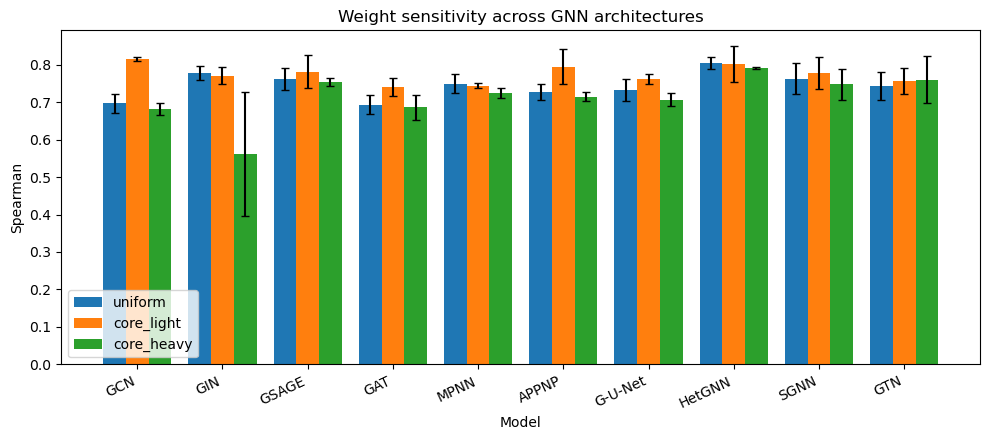

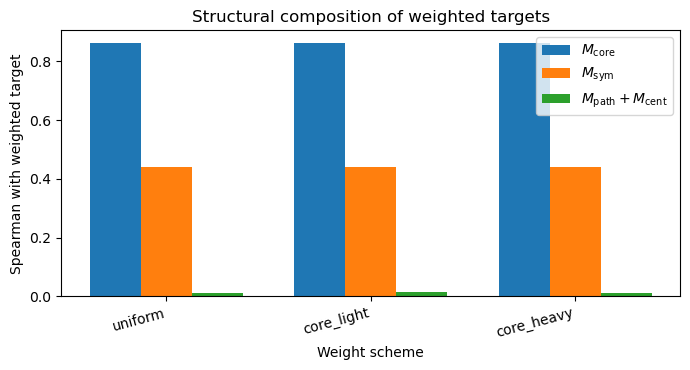

[SAVE] Spearman plot: /data/desktop/rrk307/rupesh_projects/Mutability_analysis/reviewer_weight_sensitivity_outputs_all_gnns/weight_sensitivity_all_models_spearman.pdf
[SAVE] Composition plot: /data/desktop/rrk307/rupesh_projects/Mutability_analysis/reviewer_weight_sensitivity_outputs_all_gnns/weight_sensitivity_all_models_composition.pdf

[DONE] Cell 2 completed.


In [4]:
# ============================================================
# CELL 2: Weight sensitivity using the remaining 9 GNNs
# ============================================================
#
# Run this after Cell 1.
#
# Required from Cell 1:
#   data_list
#   WEIGHT_SCHEMES
#   M_core_fast, M_sym_fast, M_flow_fast attached to each graph
#
# This cell evaluates:
#   GIN, GSAGE, GAT, MPNN, APPNP, G-U-Net, HetGNN, SGNN, GTN
#
# It uses the same fast target construction:
#   M_w = w_path*(M_path + M_cent) + w_core*M_core + w_sym*M_sym
# where w_path == w_cent in the fast residual setting.

import os
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    GINConv,
    SAGEConv,
    GATConv,
    APPNP,
    GraphUNet,
    TransformerConv,
    MessagePassing,
)

# -----------------------------
# Configuration
# -----------------------------

OUTPUT_DIR_CELL2 = Path("reviewer_weight_sensitivity_outputs_all_gnns")
OUTPUT_DIR_CELL2.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Match Cell 1 settings as much as possible.
SEEDS_CELL2 = globals().get("SEEDS", [0, 1])
TRAIN_RATIO_CELL2 = globals().get("TRAIN_RATIO", 0.8)
BATCH_SIZE_CELL2 = globals().get("BATCH_SIZE", 4)
HIDDEN_DIM_CELL2 = globals().get("HIDDEN_DIM", 64)
NUM_LAYERS_CELL2 = globals().get("NUM_LAYERS", 3)
LR_CELL2 = globals().get("LR", 1e-3)

# Keep this modest for runtime. Increase to 30 if runtime is acceptable.
NUM_EPOCHS_CELL2 = globals().get("NUM_EPOCHS", 10)

# Remaining 9 architectures used in the paper.
MODELS_TO_RUN = [
    "GIN",
    "GSAGE",
    "GAT",
    "MPNN",
    "APPNP",
    "G-U-Net",
    "HetGNN",
    "SGNN",
    "GTN",
]

# Optional: if you only want to debug first, uncomment this.
# MODELS_TO_RUN = ["GIN", "GSAGE"]

print("[INFO] Cell 2 device:", DEVICE)
print("[INFO] Models:", MODELS_TO_RUN)
print("[INFO] Seeds:", SEEDS_CELL2)
print("[INFO] Epochs:", NUM_EPOCHS_CELL2)
print("[INFO] Output directory:", OUTPUT_DIR_CELL2.resolve())

# -----------------------------
# Required-variable checks
# -----------------------------

if "data_list" not in globals() or len(data_list) == 0:
    raise RuntimeError("data_list is missing or empty. Run Cell 1 first.")

if "WEIGHT_SCHEMES" not in globals():
    raise RuntimeError("WEIGHT_SCHEMES is missing. Run Cell 1 first.")

for d in data_list:
    for attr in ["M_core_fast", "M_sym_fast", "M_flow_fast", "gate_mask"]:
        if not hasattr(d, attr):
            raise RuntimeError(
                f"Graph {getattr(d, 'circuit_name', '<unknown>')} is missing {attr}. "
                "Run Cell 1 first."
            )

# Infer gate-type feature size.
if "all_gate_types" in globals():
    NUM_GATE_TYPES_CELL2 = len(all_gate_types)
else:
    # Your feature layout is [gate_type_one_hot, is_input, is_output, fan_in, fan_out].
    NUM_GATE_TYPES_CELL2 = data_list[0].x.size(-1) - 4

print("[INFO] Input feature dimension:", data_list[0].x.size(-1))
print("[INFO] Inferred #gate types:", NUM_GATE_TYPES_CELL2)


# ============================================================
# Utility functions
# ============================================================

def set_seed_cell2(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def spearmanr_np_cell2(y_true, y_pred):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    if y_true.size < 2:
        return np.nan

    r1 = pd.Series(y_true).rank(method="average").to_numpy()
    r2 = pd.Series(y_pred).rank(method="average").to_numpy()

    r1_mean = r1.mean()
    r2_mean = r2.mean()

    num = np.sum((r1 - r1_mean) * (r2 - r2_mean))
    den = np.sqrt(np.sum((r1 - r1_mean) ** 2) * np.sum((r2 - r2_mean) ** 2))

    if den == 0:
        return np.nan
    return float(num / den)


def mean_std_str_cell2(values, precision=4):
    values = pd.Series(values).dropna().astype(float)
    if len(values) == 0:
        return "nan"
    if len(values) == 1:
        return f"{values.iloc[0]:.{precision}f}"
    return f"{values.mean():.{precision}f} ± {values.std(ddof=1):.{precision}f}"


def weighted_target_from_fast_components(d, weights):
    """
    Fast residual target:
      weights = (w_path, w_core, w_sym, w_cent)
      requires w_path == w_cent

      M_w = w_path*(M_path + M_cent) + w_core*M_core + w_sym*M_sym
    """
    w_path, w_core, w_sym, w_cent = [float(x) for x in weights]

    if abs(w_path - w_cent) > 1e-8:
        raise ValueError(
            "Fast residual mode requires w_path == w_cent because "
            "M_path and M_cent are available only through their sum."
        )

    target = (
        w_path * d.M_flow_fast +
        w_core * d.M_core_fast +
        w_sym  * d.M_sym_fast
    ).float()

    return target


def clone_with_weighted_target_cell2(dataset, weights):
    """
    Creates fresh Data objects with weighted target and per-circuit normalization.
    Also preserves fast component tensors and signed negative edges when present.
    """
    new_dataset = []

    for d in dataset:
        target = weighted_target_from_fast_components(d, weights)

        nd = Data(
            x=d.x.clone(),
            edge_index=d.edge_index.clone(),
            y=target.clone(),
        )

        nd.gate_mask = d.gate_mask.clone()
        nd.circuit_name = d.circuit_name

        nd.M_core_fast = d.M_core_fast.clone()
        nd.M_sym_fast = d.M_sym_fast.clone()
        nd.M_flow_fast = d.M_flow_fast.clone()

        if hasattr(d, "neg_edge_index_fast"):
            nd.neg_edge_index = d.neg_edge_index_fast.clone()

        gate_mask = nd.gate_mask
        y_gate = nd.y[gate_mask]

        if y_gate.numel() == 0:
            mean = 0.0
            std = 1.0
        else:
            mean = y_gate.mean().item()
            std = y_gate.std().item()
            if std < 1e-6:
                std = 1.0

        nd.y_mean = torch.full_like(nd.y, mean)
        nd.y_std = torch.full_like(nd.y, std)
        nd.y_norm = (nd.y - nd.y_mean) / nd.y_std

        new_dataset.append(nd)

    return new_dataset


# ============================================================
# Negative edges for SGNN-like model
# ============================================================

def build_negative_edges_for_graph(d, seed=0, max_neg_edges=50000):
    """
    Build random negative edges for SGNN-like signed propagation.
    This is intentionally simple and fast; it is not meant to model
    true signed circuit semantics.
    """
    rng = random.Random(seed + abs(hash(str(d.circuit_name))) % 1000000)

    n = int(d.num_nodes)
    edge_index = d.edge_index.cpu().numpy()

    pos = set()
    for u, v in edge_index.T:
        u = int(u)
        v = int(v)
        if u != v:
            pos.add((u, v))

    target_m = min(edge_index.shape[1], max_neg_edges)

    neg = set()
    attempts = 0
    max_attempts = max(1000, 20 * target_m)

    while len(neg) < target_m and attempts < max_attempts:
        u = rng.randrange(n)
        v = rng.randrange(n)
        attempts += 1

        if u == v:
            continue
        if (u, v) in pos:
            continue
        if (u, v) in neg:
            continue

        neg.add((u, v))

    if len(neg) == 0:
        return torch.zeros((2, 0), dtype=torch.long)

    neg_edge_index = torch.tensor(list(neg), dtype=torch.long).t().contiguous()
    return neg_edge_index


def ensure_negative_edges_for_base_graphs(data_list, seed=0):
    for d in data_list:
        if not hasattr(d, "neg_edge_index_fast"):
            d.neg_edge_index_fast = build_negative_edges_for_graph(d, seed=seed)

print("[INFO] Preparing negative edges for SGNN-like model...")
ensure_negative_edges_for_base_graphs(data_list, seed=123)
print("[INFO] Negative edges prepared.")


# ============================================================
# Model definitions
# All models expose forward(data) -> [num_nodes, 1]
# ============================================================

class BaseModelWrapper(nn.Module):
    def forward(self, data):
        raise NotImplementedError


class GINRegressorCell2(BaseModelWrapper):
    def __init__(self, in_dim, hidden_dim=64, num_layers=3):
        super().__init__()
        self.convs = nn.ModuleList()

        def make_mlp(in_ch, out_ch):
            return nn.Sequential(
                nn.Linear(in_ch, out_ch),
                nn.ReLU(),
                nn.Linear(out_ch, out_ch),
            )

        self.convs.append(GINConv(make_mlp(in_dim, hidden_dim)))
        for _ in range(num_layers - 1):
            self.convs.append(GINConv(make_mlp(hidden_dim, hidden_dim)))

        self.act = nn.ReLU()
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        h = data.x
        for conv in self.convs:
            h = conv(h, data.edge_index)
            h = self.act(h)
        return self.out(h)


class SAGERegressorCell2(BaseModelWrapper):
    def __init__(self, in_dim, hidden_dim=64, num_layers=3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_dim, hidden_dim))
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))
        self.act = nn.ReLU()
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        h = data.x
        for conv in self.convs:
            h = conv(h, data.edge_index)
            h = self.act(h)
        return self.out(h)


class GATRegressorCell2(BaseModelWrapper):
    def __init__(self, in_dim, hidden_dim=64, num_layers=3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GATConv(in_dim, hidden_dim, heads=1, concat=False))
        for _ in range(num_layers - 1):
            self.convs.append(GATConv(hidden_dim, hidden_dim, heads=1, concat=False))
        self.act = nn.ELU()
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        h = data.x
        for conv in self.convs:
            h = conv(h, data.edge_index)
            h = self.act(h)
        return self.out(h)


class SimpleMPNNConv(MessagePassing):
    def __init__(self, in_dim, out_dim):
        super().__init__(aggr="mean")
        self.lin_msg = nn.Linear(in_dim, out_dim)
        self.lin_root = nn.Linear(in_dim, out_dim)

    def forward(self, x, edge_index):
        return self.lin_root(x) + self.propagate(edge_index, x=x)

    def message(self, x_j):
        return self.lin_msg(x_j)


class MPNNRegressorCell2(BaseModelWrapper):
    def __init__(self, in_dim, hidden_dim=64, num_layers=3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SimpleMPNNConv(in_dim, hidden_dim))
        for _ in range(num_layers - 1):
            self.convs.append(SimpleMPNNConv(hidden_dim, hidden_dim))
        self.act = nn.ReLU()
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        h = data.x
        for conv in self.convs:
            h = conv(h, data.edge_index)
            h = self.act(h)
        return self.out(h)


class APPNPRegressorCell2(BaseModelWrapper):
    def __init__(self, in_dim, hidden_dim=64, num_layers=3, K=10, alpha=0.1):
        super().__init__()
        # Keep MLP depth comparable to other 3-layer models.
        layers = []
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.ReLU())
        for _ in range(max(0, num_layers - 2)):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
        self.mlp = nn.Sequential(*layers)
        self.prop = APPNP(K=K, alpha=alpha)
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        h = self.mlp(data.x)
        h = self.prop(h, data.edge_index)
        return self.out(h)


class GraphUNetRegressorCell2(BaseModelWrapper):
    def __init__(self, in_dim, hidden_dim=64, depth=2):
        super().__init__()
        self.unet = GraphUNet(
            in_channels=in_dim,
            hidden_channels=hidden_dim,
            out_channels=hidden_dim,
            depth=depth,
            pool_ratios=0.8,
        )
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        batch = getattr(data, "batch", None)
        h = self.unet(data.x, data.edge_index, batch=batch)
        return self.out(h)


class HetGNNRegressorCell2(BaseModelWrapper):
    """
    Homogeneous graph with explicit node-type embedding.
    This keeps the architecture close to GCN-style message passing,
    while adding type awareness for gate/input/output nodes.
    """
    def __init__(self, in_dim, hidden_dim=64, num_layers=3, num_gate_types=0):
        super().__init__()
        self.num_gate_types = int(num_gate_types)
        self.num_type_ids = self.num_gate_types + 3  # gate types + input + output + unknown
        self.type_emb = nn.Embedding(self.num_type_ids, hidden_dim // 2)

        self.input_lin = nn.Linear(in_dim + hidden_dim // 2, hidden_dim)

        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))

        self.act = nn.ReLU()
        self.out = nn.Linear(hidden_dim, 1)

    def infer_type_ids(self, x):
        n = x.size(0)
        device = x.device

        if self.num_gate_types <= 0:
            return torch.zeros(n, dtype=torch.long, device=device)

        gate_one_hot = x[:, :self.num_gate_types]
        gate_type = torch.argmax(gate_one_hot, dim=1)
        max_gate_val = torch.max(gate_one_hot, dim=1).values

        input_col = self.num_gate_types + 0
        output_col = self.num_gate_types + 1

        type_ids = gate_type.clone()
        unknown_id = self.num_gate_types + 2
        input_id = self.num_gate_types
        output_id = self.num_gate_types + 1

        type_ids[max_gate_val <= 0] = unknown_id

        if input_col < x.size(1):
            type_ids[x[:, input_col] > 0.5] = input_id
        if output_col < x.size(1):
            type_ids[x[:, output_col] > 0.5] = output_id

        return type_ids.long()

    def forward(self, data):
        type_ids = self.infer_type_ids(data.x)
        type_features = self.type_emb(type_ids)

        h = torch.cat([data.x, type_features], dim=-1)
        h = self.input_lin(h)
        h = self.act(h)

        for conv in self.convs:
            h = conv(h, data.edge_index)
            h = self.act(h)

        return self.out(h)


class SGNNRegressorCell2(BaseModelWrapper):
    """
    SGNN-like signed model using original edges as positive edges and
    randomly sampled non-edges as negative edges.
    """
    def __init__(self, in_dim, hidden_dim=64, num_layers=3):
        super().__init__()
        self.pos_convs = nn.ModuleList()
        self.neg_convs = nn.ModuleList()
        self.mix_lins = nn.ModuleList()

        self.pos_convs.append(SAGEConv(in_dim, hidden_dim))
        self.neg_convs.append(SAGEConv(in_dim, hidden_dim))
        self.mix_lins.append(nn.Linear(2 * hidden_dim, hidden_dim))

        for _ in range(num_layers - 1):
            self.pos_convs.append(SAGEConv(hidden_dim, hidden_dim))
            self.neg_convs.append(SAGEConv(hidden_dim, hidden_dim))
            self.mix_lins.append(nn.Linear(2 * hidden_dim, hidden_dim))

        self.act = nn.ReLU()
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        h = data.x
        neg_edge_index = getattr(data, "neg_edge_index", None)
        if neg_edge_index is None:
            neg_edge_index = torch.zeros((2, 0), dtype=torch.long, device=h.device)

        for pos_conv, neg_conv, mix_lin in zip(self.pos_convs, self.neg_convs, self.mix_lins):
            h_pos = pos_conv(h, data.edge_index)
            h_neg = neg_conv(h, neg_edge_index)
            h = torch.cat([h_pos, h_neg], dim=-1)
            h = mix_lin(h)
            h = self.act(h)

        return self.out(h)


class GTNRegressorCell2(BaseModelWrapper):
    """
    TransformerConv-based graph-transformer-style model.
    Heads are kept at 1 and concat=False to keep dimensionality comparable.
    """
    def __init__(self, in_dim, hidden_dim=64, num_layers=3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(TransformerConv(in_dim, hidden_dim, heads=1, concat=False))
        for _ in range(num_layers - 1):
            self.convs.append(TransformerConv(hidden_dim, hidden_dim, heads=1, concat=False))
        self.act = nn.ReLU()
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        h = data.x
        for conv in self.convs:
            h = conv(h, data.edge_index)
            h = self.act(h)
        return self.out(h)


def make_model_cell2(model_name, in_dim):
    if model_name == "GIN":
        return GINRegressorCell2(in_dim, HIDDEN_DIM_CELL2, NUM_LAYERS_CELL2)
    if model_name == "GSAGE":
        return SAGERegressorCell2(in_dim, HIDDEN_DIM_CELL2, NUM_LAYERS_CELL2)
    if model_name == "GAT":
        return GATRegressorCell2(in_dim, HIDDEN_DIM_CELL2, NUM_LAYERS_CELL2)
    if model_name == "MPNN":
        return MPNNRegressorCell2(in_dim, HIDDEN_DIM_CELL2, NUM_LAYERS_CELL2)
    if model_name == "APPNP":
        return APPNPRegressorCell2(in_dim, HIDDEN_DIM_CELL2, NUM_LAYERS_CELL2)
    if model_name == "G-U-Net":
        return GraphUNetRegressorCell2(in_dim, HIDDEN_DIM_CELL2, depth=2)
    if model_name == "HetGNN":
        return HetGNNRegressorCell2(
            in_dim,
            HIDDEN_DIM_CELL2,
            NUM_LAYERS_CELL2,
            num_gate_types=NUM_GATE_TYPES_CELL2,
        )
    if model_name == "SGNN":
        return SGNNRegressorCell2(in_dim, HIDDEN_DIM_CELL2, NUM_LAYERS_CELL2)
    if model_name == "GTN":
        return GTNRegressorCell2(in_dim, HIDDEN_DIM_CELL2, NUM_LAYERS_CELL2)

    raise ValueError(f"Unknown model_name: {model_name}")


# ============================================================
# Training and evaluation
# ============================================================

def train_and_evaluate_model_cell2(model_name, train_dataset, test_dataset, seed):
    set_seed_cell2(seed)

    in_dim = train_dataset[0].x.size(-1)
    model = make_model_cell2(model_name, in_dim).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR_CELL2)
    loss_fn = nn.MSELoss()

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_CELL2, shuffle=True)

    model.train()
    for epoch in range(1, NUM_EPOCHS_CELL2 + 1):
        total_loss = 0.0
        total_gates = 0

        for batch in train_loader:
            batch = batch.to(DEVICE)

            pred_norm = model(batch)
            gate_mask = batch.gate_mask

            pred_gate_norm = pred_norm[gate_mask]
            y_gate_norm = batch.y_norm[gate_mask]

            if pred_gate_norm.numel() == 0:
                continue

            loss = loss_fn(pred_gate_norm, y_gate_norm)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            num_gates = int(gate_mask.sum().item())
            total_loss += float(loss.item()) * num_gates
            total_gates += num_gates

        avg_loss = total_loss / max(1, total_gates)

    # Evaluation.
    model.eval()

    all_true = []
    all_pred = []
    all_core = []
    all_sym = []
    all_flow = []

    per_circuit_rows = []

    with torch.no_grad():
        for data in test_dataset:
            d = data.to(DEVICE)

            pred_norm = model(d)
            pred = (pred_norm * d.y_std + d.y_mean).cpu().numpy().flatten()

            y_true = d.y.cpu().numpy().flatten()
            gate_mask = d.gate_mask.cpu().numpy().astype(bool)

            y_gate = y_true[gate_mask]
            pred_gate = pred[gate_mask]

            if y_gate.size == 0:
                continue

            core_gate = data.M_core_fast.cpu().numpy().flatten()[gate_mask]
            sym_gate = data.M_sym_fast.cpu().numpy().flatten()[gate_mask]
            flow_gate = data.M_flow_fast.cpu().numpy().flatten()[gate_mask]

            all_true.append(y_gate)
            all_pred.append(pred_gate)
            all_core.append(core_gate)
            all_sym.append(sym_gate)
            all_flow.append(flow_gate)

            per_circuit_rows.append({
                "model": model_name,
                "seed": seed,
                "circuit": data.circuit_name,
                "num_gate_nodes": int(gate_mask.sum()),
                "mse": float(np.mean((y_gate - pred_gate) ** 2)),
                "mae": float(np.mean(np.abs(y_gate - pred_gate))),
                "spearman": spearmanr_np_cell2(y_gate, pred_gate),
            })

    all_true = np.concatenate(all_true, axis=0)
    all_pred = np.concatenate(all_pred, axis=0)
    all_core = np.concatenate(all_core, axis=0)
    all_sym = np.concatenate(all_sym, axis=0)
    all_flow = np.concatenate(all_flow, axis=0)

    result = {
        "mse": float(np.mean((all_true - all_pred) ** 2)),
        "mae": float(np.mean(np.abs(all_true - all_pred))),
        "spearman": spearmanr_np_cell2(all_true, all_pred),
        "target_std": float(np.std(all_true)),
        "rho_target_core": spearmanr_np_cell2(all_true, all_core),
        "rho_target_sym": spearmanr_np_cell2(all_true, all_sym),
        "rho_target_flow": spearmanr_np_cell2(all_true, all_flow),
    }

    return result, per_circuit_rows


# ============================================================
# Main multi-model experiment
# ============================================================

raw_rows = []
per_circuit_rows = []

for seed in SEEDS_CELL2:
    print("\n" + "=" * 90)
    print(f"[SEED {seed}]")

    indices = list(range(len(data_list)))
    rnd = random.Random(seed)
    rnd.shuffle(indices)

    split = int(TRAIN_RATIO_CELL2 * len(indices))
    train_indices = indices[:split]
    test_indices = indices[split:]

    train_base = [data_list[i] for i in train_indices]
    test_base = [data_list[i] for i in test_indices]

    print("[SPLIT] Train:", [d.circuit_name for d in train_base])
    print("[SPLIT] Test :", [d.circuit_name for d in test_base])

    for scheme_name, weights in WEIGHT_SCHEMES.items():
        print("\n" + "-" * 90)
        print(f"[SCHEME] {scheme_name}: weights={np.round(weights, 4).tolist()}")

        train_dataset = clone_with_weighted_target_cell2(train_base, weights)
        test_dataset = clone_with_weighted_target_cell2(test_base, weights)

        for model_name in MODELS_TO_RUN:
            print(f"[RUN] seed={seed}, scheme={scheme_name}, model={model_name}")

            try:
                result, pc_rows = train_and_evaluate_model_cell2(
                    model_name=model_name,
                    train_dataset=train_dataset,
                    test_dataset=test_dataset,
                    seed=seed,
                )

                row = {
                    "model": model_name,
                    "seed": seed,
                    "scheme": scheme_name,
                    "w_path": float(weights[0]),
                    "w_core": float(weights[1]),
                    "w_sym": float(weights[2]),
                    "w_cent": float(weights[3]),
                    "status": "ok",
                    "error": "",
                }
                row.update(result)
                raw_rows.append(row)

                for pc in pc_rows:
                    pc.update({
                        "scheme": scheme_name,
                        "w_path": float(weights[0]),
                        "w_core": float(weights[1]),
                        "w_sym": float(weights[2]),
                        "w_cent": float(weights[3]),
                    })
                    per_circuit_rows.append(pc)

                print(
                    f"      MSE={result['mse']:.6f}, "
                    f"MAE={result['mae']:.6f}, "
                    f"Spearman={result['spearman']:.4f}, "
                    f"rho_core={result['rho_target_core']:.4f}, "
                    f"rho_flow={result['rho_target_flow']:.4f}"
                )

            except Exception as e:
                print(f"      [ERROR] {model_name} failed: {repr(e)}")
                raw_rows.append({
                    "model": model_name,
                    "seed": seed,
                    "scheme": scheme_name,
                    "w_path": float(weights[0]),
                    "w_core": float(weights[1]),
                    "w_sym": float(weights[2]),
                    "w_cent": float(weights[3]),
                    "status": "failed",
                    "error": repr(e),
                    "mse": np.nan,
                    "mae": np.nan,
                    "spearman": np.nan,
                    "target_std": np.nan,
                    "rho_target_core": np.nan,
                    "rho_target_sym": np.nan,
                    "rho_target_flow": np.nan,
                })


# ============================================================
# Save raw outputs
# ============================================================

results_9gnn_df = pd.DataFrame(raw_rows)
per_circuit_9gnn_df = pd.DataFrame(per_circuit_rows)

raw_csv = OUTPUT_DIR_CELL2 / "weight_sensitivity_remaining_9gnns_raw.csv"
pc_csv = OUTPUT_DIR_CELL2 / "weight_sensitivity_remaining_9gnns_per_circuit.csv"

results_9gnn_df.to_csv(raw_csv, index=False)
per_circuit_9gnn_df.to_csv(pc_csv, index=False)

print("\n[SAVE] Raw 9-GNN results:", raw_csv.resolve())
print("[SAVE] Per-circuit 9-GNN results:", pc_csv.resolve())


# ============================================================
# Optional: combine with Cell 1 GCN results if available
# ============================================================

combined_df = results_9gnn_df.copy()

gcn_raw_path_candidates = [
    Path("reviewer_weight_sensitivity_outputs_fast") / "weight_sensitivity_fast_raw.csv",
    Path("reviewer_weight_sensitivity_outputs") / "weight_sensitivity_fast_raw.csv",
    Path("reviewer_weight_sensitivity_outputs_fast") / "weight_sensitivity_gcn_raw_results.csv",
]

gcn_found = False
for gcn_path in gcn_raw_path_candidates:
    if gcn_path.exists():
        gcn_df = pd.read_csv(gcn_path)
        if "model" not in gcn_df.columns:
            gcn_df.insert(0, "model", "GCN")
        if "status" not in gcn_df.columns:
            gcn_df["status"] = "ok"
        if "error" not in gcn_df.columns:
            gcn_df["error"] = ""

        # Align columns.
        for col in combined_df.columns:
            if col not in gcn_df.columns:
                gcn_df[col] = np.nan
        for col in gcn_df.columns:
            if col not in combined_df.columns:
                combined_df[col] = np.nan

        combined_df = pd.concat([gcn_df[combined_df.columns], combined_df], ignore_index=True)
        print("[INFO] Included GCN results from:", gcn_path.resolve())
        gcn_found = True
        break

if not gcn_found:
    print("[INFO] No Cell 1 GCN raw file found. Combined summary will include only the remaining 9 GNNs.")


# ============================================================
# Summaries
# ============================================================

def build_summary_table(df):
    rows = []
    ok_df = df[df["status"] == "ok"].copy()

    model_order = ["GCN"] + MODELS_TO_RUN
    scheme_order = list(WEIGHT_SCHEMES.keys())

    for model in model_order:
        for scheme in scheme_order:
            group = ok_df[(ok_df["model"] == model) & (ok_df["scheme"] == scheme)]
            if len(group) == 0:
                continue

            rows.append({
                "model": model,
                "scheme": scheme,
                "weights": "(" + ", ".join([
                    f"{group['w_path'].mean():.2f}",
                    f"{group['w_core'].mean():.2f}",
                    f"{group['w_sym'].mean():.2f}",
                    f"{group['w_cent'].mean():.2f}",
                ]) + ")",
                "mse": mean_std_str_cell2(group["mse"], precision=6),
                "mae": mean_std_str_cell2(group["mae"], precision=6),
                "spearman": mean_std_str_cell2(group["spearman"], precision=4),
                "rho_core": mean_std_str_cell2(group["rho_target_core"], precision=4),
                "rho_sym": mean_std_str_cell2(group["rho_target_sym"], precision=4),
                "rho_flow": mean_std_str_cell2(group["rho_target_flow"], precision=4),
                "target_std": mean_std_str_cell2(group["target_std"], precision=4),
            })

    return pd.DataFrame(rows)

summary_9gnn_df = build_summary_table(results_9gnn_df)
summary_combined_df = build_summary_table(combined_df)

summary_9gnn_csv = OUTPUT_DIR_CELL2 / "weight_sensitivity_remaining_9gnns_summary.csv"
summary_combined_csv = OUTPUT_DIR_CELL2 / "weight_sensitivity_all_models_summary.csv"

summary_9gnn_df.to_csv(summary_9gnn_csv, index=False)
summary_combined_df.to_csv(summary_combined_csv, index=False)

print("\n=== Summary: Remaining 9 GNNs ===")
try:
    display(summary_9gnn_df)
except NameError:
    print(summary_9gnn_df.to_string(index=False))

print("\n=== Summary: All Models Including GCN if Available ===")
try:
    display(summary_combined_df)
except NameError:
    print(summary_combined_df.to_string(index=False))

print("[SAVE] 9-GNN summary:", summary_9gnn_csv.resolve())
print("[SAVE] Combined summary:", summary_combined_csv.resolve())


# ============================================================
# Compact pivot summaries for quick reading
# ============================================================

ok_combined = combined_df[combined_df["status"] == "ok"].copy()

pivot_spearman = ok_combined.pivot_table(
    index="model",
    columns="scheme",
    values="spearman",
    aggfunc="mean",
)

pivot_mse = ok_combined.pivot_table(
    index="model",
    columns="scheme",
    values="mse",
    aggfunc="mean",
)

pivot_spearman_csv = OUTPUT_DIR_CELL2 / "pivot_spearman_mean.csv"
pivot_mse_csv = OUTPUT_DIR_CELL2 / "pivot_mse_mean.csv"

pivot_spearman.to_csv(pivot_spearman_csv)
pivot_mse.to_csv(pivot_mse_csv)

print("\n=== Mean Spearman Pivot ===")
try:
    display(pivot_spearman)
except NameError:
    print(pivot_spearman.to_string())

print("\n=== Mean MSE Pivot ===")
try:
    display(pivot_mse)
except NameError:
    print(pivot_mse.to_string())

print("[SAVE] Spearman pivot:", pivot_spearman_csv.resolve())
print("[SAVE] MSE pivot:", pivot_mse_csv.resolve())


# ============================================================
# LaTeX table drafts
# ============================================================

latex_perf_cols = ["model", "scheme", "weights", "mse", "mae", "spearman"]
latex_perf_df = summary_combined_df[latex_perf_cols].copy()
latex_perf_df.columns = ["Model", "Scheme", "Weights", "MSE", "MAE", "Spearman"]

latex_perf_text = latex_perf_df.to_latex(index=False, escape=False)
latex_perf_path = OUTPUT_DIR_CELL2 / "weight_sensitivity_all_models_performance_table.tex"
latex_perf_path.write_text(latex_perf_text)

latex_comp_cols = ["scheme", "weights", "rho_core", "rho_sym", "rho_flow", "target_std"]
# Target composition is independent of architecture, so keep one row per scheme.
latex_comp_df = summary_combined_df.drop_duplicates(subset=["scheme"])[latex_comp_cols].copy()
latex_comp_df.columns = [
    "Scheme",
    "Weights",
    r"$\rho(M_{\mathbf{w}},M_{\text{core}})$",
    r"$\rho(M_{\mathbf{w}},M_{\text{sym}})$",
    r"$\rho(M_{\mathbf{w}},M_{\text{path}}+M_{\text{cent}})$",
    r"$\sigma(M_{\mathbf{w}})$",
]

latex_comp_text = latex_comp_df.to_latex(index=False, escape=False)
latex_comp_path = OUTPUT_DIR_CELL2 / "weight_sensitivity_target_composition_table.tex"
latex_comp_path.write_text(latex_comp_text)

print("\n=== LaTeX Performance Table Draft ===")
print(latex_perf_text)
print("[SAVE] LaTeX performance table:", latex_perf_path.resolve())

print("\n=== LaTeX Target-Composition Table Draft ===")
print(latex_comp_text)
print("[SAVE] LaTeX composition table:", latex_comp_path.resolve())


# ============================================================
# Plots
# ============================================================

scheme_order = list(WEIGHT_SCHEMES.keys())
model_order = [m for m in ["GCN"] + MODELS_TO_RUN if m in ok_combined["model"].unique()]

# Plot: mean Spearman by model and weight scheme.
plt.figure(figsize=(10, 4.5))
x = np.arange(len(model_order))
width = 0.8 / max(1, len(scheme_order))

for i, scheme in enumerate(scheme_order):
    vals = []
    errs = []
    for model in model_order:
        group = ok_combined[(ok_combined["model"] == model) & (ok_combined["scheme"] == scheme)]
        vals.append(group["spearman"].mean() if len(group) else np.nan)
        errs.append(group["spearman"].std(ddof=1) if len(group) > 1 else 0.0)

    plt.bar(x + (i - (len(scheme_order)-1)/2) * width, vals, width=width, yerr=errs, capsize=3, label=scheme)

plt.xticks(x, model_order, rotation=25, ha="right")
plt.ylabel("Spearman")
plt.xlabel("Model")
plt.title("Weight sensitivity across GNN architectures")
plt.legend()
plt.tight_layout()
spearman_plot_path = OUTPUT_DIR_CELL2 / "weight_sensitivity_all_models_spearman.pdf"
plt.savefig(spearman_plot_path)
plt.show()

# Plot: target composition by scheme.
plt.figure(figsize=(7, 3.8))
comp_plot_df = ok_combined.drop_duplicates(subset=["scheme"]).set_index("scheme")
x = np.arange(len(scheme_order))
width = 0.25

rho_cols = ["rho_target_core", "rho_target_sym", "rho_target_flow"]
rho_labels = [
    r"$M_{\mathrm{core}}$",
    r"$M_{\mathrm{sym}}$",
    r"$M_{\mathrm{path}}+M_{\mathrm{cent}}$",
]

for i, col in enumerate(rho_cols):
    vals = []
    for scheme in scheme_order:
        if scheme in comp_plot_df.index:
            vals.append(comp_plot_df.loc[scheme, col])
        else:
            vals.append(np.nan)

    plt.bar(x + (i - 1) * width, vals, width=width, label=rho_labels[i])

plt.xticks(x, scheme_order, rotation=15, ha="right")
plt.ylabel("Spearman with weighted target")
plt.xlabel("Weight scheme")
plt.title("Structural composition of weighted targets")
plt.legend()
plt.tight_layout()
composition_plot_path = OUTPUT_DIR_CELL2 / "weight_sensitivity_all_models_composition.pdf"
plt.savefig(composition_plot_path)
plt.show()

print("[SAVE] Spearman plot:", spearman_plot_path.resolve())
print("[SAVE] Composition plot:", composition_plot_path.resolve())

print("\n[DONE] Cell 2 completed.")

### Cell 3: Composite Score Versus Individual Component Scores

The reviewer questioned whether the proposed composite score \(M(v)\) advances beyond individual structural metrics, especially since \(M_{\text{core}}\) dominates the component analysis. This cell compares the original composite score against individual structural targets: \(M_{\text{core}}\), \(M_{\text{sym}}\), and the available flow-related residual \((M_{\text{path}}+M_{\text{cent}})/2\). For each target, we evaluate two aspects: (i) how different its node ranking is from the original composite score using Spearman correlation and top-10% ranking overlap, and (ii) whether a representative GCN can learn the target under the same circuit-level split protocol. The goal is not to claim that the composite score is universally superior, but to test whether it is distinguishable from single-component metrics and whether it provides a multi-factor structural descriptor rather than simply duplicating \(M_{\text{core}}\).

[INFO] Cell 3 device: cpu
[INFO] Output directory: /data/desktop/rrk307/rupesh_projects/Mutability_analysis/reviewer_component_baseline_outputs
[INFO] Seeds: [0, 1]
[INFO] Required fast component tensors are available.

[SEED 0]
[SPLIT] Train: ['ctrl.v', 'c2670.v', 'c7552.v', 'c6288.v', 'int2float.v', 'c17.v', 'c1908.v', 'multiplier.v', 'div.v', 'c5315.v', 'max.v', 'sqrt.v', 'sin.v', 'c499.v', 'bar.v', 'c880.v', 'voter.v', 'router.v', 'c3540.v', 'arbiter.v', 'dec.v', 'memctrl.v', 'i2c.v', 'adder.v']
[SPLIT] Test : ['c1355.v', 'c432.v', 'Priority.v', 'square.v', 'cavlc.v', 'log2.v']

[RUN] seed=0, target=Composite
      rho(target, M)=1.0000, top10_overlap=1.0000, GCN Spearman=0.6790, MSE=0.000459

[RUN] seed=0, target=Core-only
      rho(target, M)=0.8629, top10_overlap=0.2196, GCN Spearman=0.8447, MSE=0.025813

[RUN] seed=0, target=Sym-only
      rho(target, M)=0.4403, top10_overlap=0.5627, GCN Spearman=0.5659, MSE=0.000413

[RUN] seed=0, target=Flow-only
      rho(target, M)=0.0124, 

,target,rho_with_composite,top10_overlap_with_composite,target_std,mse,mae,spearman
0,Composite,1.0000 ± 0.0000,1.0000 ± 0.0000,0.0223 ± 0.0005,0.000405 ± 0.000076,0.012738 ± 0.001812,0.6970 ± 0.0253
1,Core-only,0.8405 ± 0.0317,0.2908 ± 0.1006,0.0787 ± 0.0148,0.021444 ± 0.006179,0.097924 ± 0.026005,0.8270 ± 0.0251
2,Sym-only,0.5169 ± 0.1084,0.4725 ± 0.1276,0.0242 ± 0.0063,0.000391 ± 0.000031,0.015313 ± 0.000373,0.5600 ± 0.0083
3,Flow-only,0.1700 ± 0.2228,0.2550 ± 0.0174,0.0053 ± 0.0023,0.000002 ± 0.000002,0.000242 ± 0.000037,0.3647 ± 0.0443


[SAVE] Summary: /data/desktop/rrk307/rupesh_projects/Mutability_analysis/reviewer_component_baseline_outputs/single_component_comparison_summary.csv

=== LaTeX table draft ===
\begin{tabular}{lllllll}
\toprule
Target & $\rho(\mathrm{Target},M)$ & Top-10\% overlap & $\sigma(\mathrm{Target})$ & MSE & MAE & Spearman \\
\midrule
Composite & 1.0000 ± 0.0000 & 1.0000 ± 0.0000 & 0.0223 ± 0.0005 & 0.000405 ± 0.000076 & 0.012738 ± 0.001812 & 0.6970 ± 0.0253 \\
Core-only & 0.8405 ± 0.0317 & 0.2908 ± 0.1006 & 0.0787 ± 0.0148 & 0.021444 ± 0.006179 & 0.097924 ± 0.026005 & 0.8270 ± 0.0251 \\
Sym-only & 0.5169 ± 0.1084 & 0.4725 ± 0.1276 & 0.0242 ± 0.0063 & 0.000391 ± 0.000031 & 0.015313 ± 0.000373 & 0.5600 ± 0.0083 \\
Flow-only & 0.1700 ± 0.2228 & 0.2550 ± 0.0174 & 0.0053 ± 0.0023 & 0.000002 ± 0.000002 & 0.000242 ± 0.000037 & 0.3647 ± 0.0443 \\
\bottomrule
\end{tabular}

[SAVE] LaTeX table: /data/desktop/rrk307/rupesh_projects/Mutability_analysis/reviewer_component_baseline_outputs/single_component_c

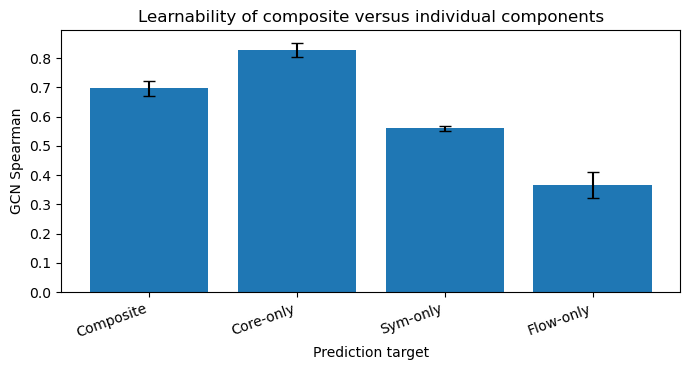

[SAVE] Plot: /data/desktop/rrk307/rupesh_projects/Mutability_analysis/reviewer_component_baseline_outputs/single_component_gcn_spearman.pdf

[DONE] Cell 3 completed.


In [6]:
# ============================================================
# CELL 3: Composite score versus individual component scores
# ============================================================
#
# Purpose:
#   Address reviewer concern:
#   "It is unclear how the proposed composite metric advances
#    over individual metrics, since one component may naturally
#    dominate depending on scenario."
#
# This cell compares:
#   1. Composite M(v)      : saved uniform target d.y
#   2. Core-only target    : M_core
#   3. Symmetry-only target: M_sym
#   4. Flow-only target    : (M_path + M_cent)/2
#
# It reports:
#   - Spearman(Target, Composite M)
#   - Top-10% ranking overlap with Composite M
#   - Target standard deviation
#   - GCN prediction MSE/MAE/Spearman for each target
#
# Run after Cell 1, because it expects M_core_fast, M_sym_fast,
# and M_flow_fast to already be attached to each graph.

import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv


# ============================================================
# 0. Configuration
# ============================================================

OUTPUT_DIR_CELL3 = Path("reviewer_component_baseline_outputs")
OUTPUT_DIR_CELL3.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SEEDS_CELL3 = [0, 1]          # increase to [0,1,2,3,4] if time permits
TRAIN_RATIO_CELL3 = 0.8
BATCH_SIZE_CELL3 = 4
HIDDEN_DIM_CELL3 = 64
NUM_LAYERS_CELL3 = 3
LR_CELL3 = 1e-3
NUM_EPOCHS_CELL3 = 10         # increase to 30 if runtime is acceptable
TOP_FRAC = 0.10

print("[INFO] Cell 3 device:", DEVICE)
print("[INFO] Output directory:", OUTPUT_DIR_CELL3.resolve())
print("[INFO] Seeds:", SEEDS_CELL3)


# ============================================================
# 1. Required checks
# ============================================================

if "data_list" not in globals() or len(data_list) == 0:
    raise RuntimeError("data_list is missing or empty. Run Cell 1 first.")

for d in data_list:
    for attr in ["gate_mask", "M_core_fast", "M_sym_fast", "M_flow_fast"]:
        if not hasattr(d, attr):
            raise RuntimeError(
                f"Graph {getattr(d, 'circuit_name', '<unknown>')} is missing {attr}. "
                "Run Cell 1 first so fast component tensors are available."
            )

print("[INFO] Required fast component tensors are available.")


# ============================================================
# 2. Helper functions
# ============================================================

def set_seed_c3(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def spearmanr_np_c3(y_true, y_pred):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    if y_true.size < 2:
        return np.nan

    r1 = pd.Series(y_true).rank(method="average").to_numpy()
    r2 = pd.Series(y_pred).rank(method="average").to_numpy()

    r1_mean = r1.mean()
    r2_mean = r2.mean()

    num = np.sum((r1 - r1_mean) * (r2 - r2_mean))
    den = np.sqrt(np.sum((r1 - r1_mean) ** 2) * np.sum((r2 - r2_mean) ** 2))

    if den == 0:
        return np.nan
    return float(num / den)


def mean_std_str_c3(values, precision=4):
    values = pd.Series(values).dropna().astype(float)
    if len(values) == 0:
        return "nan"
    if len(values) == 1:
        return f"{values.iloc[0]:.{precision}f}"
    return f"{values.mean():.{precision}f} ± {values.std(ddof=1):.{precision}f}"


def topk_overlap(y_ref, y_target, frac=0.10):
    """
    Top-k overlap between rankings induced by y_ref and y_target.
    Used to test whether a single component selects the same
    high-score nodes as the composite metric.
    """
    y_ref = np.asarray(y_ref).flatten()
    y_target = np.asarray(y_target).flatten()

    n = len(y_ref)
    if n == 0:
        return np.nan

    k = max(1, int(np.ceil(frac * n)))

    idx_ref = np.argsort(-y_ref)[:k]
    idx_tgt = np.argsort(-y_target)[:k]

    return len(set(idx_ref).intersection(set(idx_tgt))) / float(k)


def get_target_tensor(d, target_name):
    """
    Returns node-level target tensor [num_nodes,1].
    """
    if target_name == "Composite":
        return d.y.clone().float()

    if target_name == "Core-only":
        return d.M_core_fast.clone().float()

    if target_name == "Sym-only":
        return d.M_sym_fast.clone().float()

    if target_name == "Flow-only":
        # M_flow_fast = M_path + M_cent. Divide by 2 to keep scale in [0,1].
        return (0.5 * d.M_flow_fast).clone().float()

    raise ValueError(f"Unknown target_name: {target_name}")


TARGETS = ["Composite", "Core-only", "Sym-only", "Flow-only"]


# ============================================================
# 3. Dataset construction
# ============================================================

def clone_dataset_with_target(dataset, target_name):
    new_dataset = []

    for d in dataset:
        y = get_target_tensor(d, target_name)

        nd = Data(
            x=d.x.clone(),
            edge_index=d.edge_index.clone(),
            y=y.clone(),
        )

        nd.gate_mask = d.gate_mask.clone()
        nd.circuit_name = d.circuit_name

        # Preserve component tensors for statistics.
        nd.M_core_fast = d.M_core_fast.clone()
        nd.M_sym_fast = d.M_sym_fast.clone()
        nd.M_flow_fast = d.M_flow_fast.clone()

        # Per-circuit normalization on gate nodes.
        gate_mask = nd.gate_mask
        y_gate = nd.y[gate_mask]

        if y_gate.numel() == 0:
            mean = 0.0
            std = 1.0
        else:
            mean = y_gate.mean().item()
            std = y_gate.std().item()
            if std < 1e-6:
                std = 1.0

        nd.y_mean = torch.full_like(nd.y, mean)
        nd.y_std = torch.full_like(nd.y, std)
        nd.y_norm = (nd.y - nd.y_mean) / nd.y_std

        new_dataset.append(nd)

    return new_dataset


# ============================================================
# 4. GCN model
# ============================================================

class GCNRegressorC3(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_layers=3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_dim, hidden_dim))

        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))

        self.convs.append(GCNConv(hidden_dim, hidden_dim))
        self.act = nn.ReLU()
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        h = data.x
        for conv in self.convs:
            h = conv(h, data.edge_index)
            h = self.act(h)
        return self.out(h)


def train_and_evaluate_gcn_c3(train_dataset, test_dataset, seed):
    set_seed_c3(seed)

    in_dim = train_dataset[0].x.size(-1)

    model = GCNRegressorC3(
        in_dim=in_dim,
        hidden_dim=HIDDEN_DIM_CELL3,
        num_layers=NUM_LAYERS_CELL3,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR_CELL3)
    loss_fn = nn.MSELoss()

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_CELL3, shuffle=True)

    model.train()
    for epoch in range(1, NUM_EPOCHS_CELL3 + 1):
        total_loss = 0.0
        total_gates = 0

        for batch in train_loader:
            batch = batch.to(DEVICE)

            pred_norm = model(batch)
            gate_mask = batch.gate_mask

            pred_gate_norm = pred_norm[gate_mask]
            y_gate_norm = batch.y_norm[gate_mask]

            if pred_gate_norm.numel() == 0:
                continue

            loss = loss_fn(pred_gate_norm, y_gate_norm)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            n_gates = int(gate_mask.sum().item())
            total_loss += float(loss.item()) * n_gates
            total_gates += n_gates

    # Evaluation
    model.eval()

    all_true = []
    all_pred = []

    per_circuit_rows = []

    with torch.no_grad():
        for data in test_dataset:
            d = data.to(DEVICE)

            pred_norm = model(d)
            pred = (pred_norm * d.y_std + d.y_mean).cpu().numpy().flatten()

            y_true = d.y.cpu().numpy().flatten()
            gate_mask = d.gate_mask.cpu().numpy().astype(bool)

            y_gate = y_true[gate_mask]
            pred_gate = pred[gate_mask]

            if y_gate.size == 0:
                continue

            all_true.append(y_gate)
            all_pred.append(pred_gate)

            per_circuit_rows.append({
                "seed": seed,
                "circuit": data.circuit_name,
                "num_gate_nodes": int(gate_mask.sum()),
                "mse": float(np.mean((y_gate - pred_gate) ** 2)),
                "mae": float(np.mean(np.abs(y_gate - pred_gate))),
                "spearman": spearmanr_np_c3(y_gate, pred_gate),
            })

    all_true = np.concatenate(all_true, axis=0)
    all_pred = np.concatenate(all_pred, axis=0)

    result = {
        "mse": float(np.mean((all_true - all_pred) ** 2)),
        "mae": float(np.mean(np.abs(all_true - all_pred))),
        "spearman": spearmanr_np_c3(all_true, all_pred),
    }

    return result, per_circuit_rows


# ============================================================
# 5. Target statistics
# ============================================================

def compute_target_stats_for_split(test_base, target_name):
    """
    Compare each component target against the original composite M(v)
    on the same held-out circuits.
    """
    all_ref = []
    all_tgt = []
    top_overlaps = []
    target_stds = []

    for d in test_base:
        gate_mask = d.gate_mask.cpu().numpy().astype(bool)

        y_ref = d.y.cpu().numpy().flatten()[gate_mask]
        y_tgt = get_target_tensor(d, target_name).cpu().numpy().flatten()[gate_mask]

        if y_ref.size == 0:
            continue

        all_ref.append(y_ref)
        all_tgt.append(y_tgt)
        top_overlaps.append(topk_overlap(y_ref, y_tgt, frac=TOP_FRAC))
        target_stds.append(float(np.std(y_tgt)))

    all_ref = np.concatenate(all_ref, axis=0)
    all_tgt = np.concatenate(all_tgt, axis=0)

    return {
        "rho_with_composite": spearmanr_np_c3(all_ref, all_tgt),
        "top10_overlap_with_composite": float(np.nanmean(top_overlaps)),
        "target_std": float(np.nanmean(target_stds)),
    }


# ============================================================
# 6. Main experiment
# ============================================================

raw_rows = []
per_circuit_rows = []
target_stat_rows = []

for seed in SEEDS_CELL3:
    print("\n" + "=" * 80)
    print(f"[SEED {seed}]")

    indices = list(range(len(data_list)))
    rnd = random.Random(seed)
    rnd.shuffle(indices)

    split = int(TRAIN_RATIO_CELL3 * len(indices))
    train_indices = indices[:split]
    test_indices = indices[split:]

    train_base = [data_list[i] for i in train_indices]
    test_base = [data_list[i] for i in test_indices]

    print("[SPLIT] Train:", [d.circuit_name for d in train_base])
    print("[SPLIT] Test :", [d.circuit_name for d in test_base])

    for target_name in TARGETS:
        print(f"\n[RUN] seed={seed}, target={target_name}")

        stats = compute_target_stats_for_split(test_base, target_name)
        stat_row = {
            "seed": seed,
            "target": target_name,
        }
        stat_row.update(stats)
        target_stat_rows.append(stat_row)

        train_dataset = clone_dataset_with_target(train_base, target_name)
        test_dataset = clone_dataset_with_target(test_base, target_name)

        result, pc_rows = train_and_evaluate_gcn_c3(
            train_dataset=train_dataset,
            test_dataset=test_dataset,
            seed=seed,
        )

        row = {
            "seed": seed,
            "target": target_name,
        }
        row.update(stats)
        row.update(result)
        raw_rows.append(row)

        for pc in pc_rows:
            pc["target"] = target_name
            per_circuit_rows.append(pc)

        print(
            f"      rho(target, M)={stats['rho_with_composite']:.4f}, "
            f"top10_overlap={stats['top10_overlap_with_composite']:.4f}, "
            f"GCN Spearman={result['spearman']:.4f}, "
            f"MSE={result['mse']:.6f}"
        )


# ============================================================
# 7. Summaries and outputs
# ============================================================

results_df = pd.DataFrame(raw_rows)
per_circuit_df = pd.DataFrame(per_circuit_rows)
target_stats_df = pd.DataFrame(target_stat_rows)

raw_csv = OUTPUT_DIR_CELL3 / "single_component_comparison_raw.csv"
pc_csv = OUTPUT_DIR_CELL3 / "single_component_comparison_per_circuit.csv"
target_stats_csv = OUTPUT_DIR_CELL3 / "single_component_target_stats_raw.csv"

results_df.to_csv(raw_csv, index=False)
per_circuit_df.to_csv(pc_csv, index=False)
target_stats_df.to_csv(target_stats_csv, index=False)

print("\n[SAVE] Raw results:", raw_csv.resolve())
print("[SAVE] Per-circuit results:", pc_csv.resolve())
print("[SAVE] Target stats:", target_stats_csv.resolve())

summary_rows = []

for target_name in TARGETS:
    group = results_df[results_df["target"] == target_name]

    summary_rows.append({
        "target": target_name,
        "rho_with_composite": mean_std_str_c3(group["rho_with_composite"], precision=4),
        "top10_overlap_with_composite": mean_std_str_c3(group["top10_overlap_with_composite"], precision=4),
        "target_std": mean_std_str_c3(group["target_std"], precision=4),
        "mse": mean_std_str_c3(group["mse"], precision=6),
        "mae": mean_std_str_c3(group["mae"], precision=6),
        "spearman": mean_std_str_c3(group["spearman"], precision=4),
    })

summary_df = pd.DataFrame(summary_rows)

summary_csv = OUTPUT_DIR_CELL3 / "single_component_comparison_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print("\n=== Composite versus individual component summary ===")
try:
    display(summary_df)
except NameError:
    print(summary_df.to_string(index=False))

print("[SAVE] Summary:", summary_csv.resolve())


# ============================================================
# 8. LaTeX table draft
# ============================================================

latex_df = summary_df.copy()
latex_df.columns = [
    "Target",
    r"$\rho(\mathrm{Target},M)$",
    "Top-10\\% overlap",
    r"$\sigma(\mathrm{Target})$",
    "MSE",
    "MAE",
    "Spearman",
]

latex_text = latex_df.to_latex(index=False, escape=False)
latex_path = OUTPUT_DIR_CELL3 / "single_component_comparison_table.tex"
latex_path.write_text(latex_text)

print("\n=== LaTeX table draft ===")
print(latex_text)
print("[SAVE] LaTeX table:", latex_path.resolve())


# ============================================================
# 9. Plot
# ============================================================

plot_df = results_df.copy()
target_order = TARGETS

plt.figure(figsize=(7, 3.8))
x = np.arange(len(target_order))

means = plot_df.groupby("target")["spearman"].mean().reindex(target_order)
stds = plot_df.groupby("target")["spearman"].std().reindex(target_order).fillna(0.0)

plt.bar(x, means.values, yerr=stds.values, capsize=4)
plt.xticks(x, target_order, rotation=20, ha="right")
plt.ylabel("GCN Spearman")
plt.xlabel("Prediction target")
plt.title("Learnability of composite versus individual components")
plt.tight_layout()

plot_path = OUTPUT_DIR_CELL3 / "single_component_gcn_spearman.pdf"
plt.savefig(plot_path)
plt.show()

print("[SAVE] Plot:", plot_path.resolve())
print("\n[DONE] Cell 3 completed.")